# 🏠 Housing Affordability Analysis — Phase 3: Regression Analysis
### Identifying Key Drivers of Home Prices Using Linear Regression

| | |
|---|---|
| **Author** | Yaw Assensoh Opoku |
| **Cities** | New York · Los Angeles · Chicago · Houston · Miami |
| **Period** | January 2015 — December 2024 |
| **Tools** | Python · Pandas · Scikit-learn · Statsmodels · Matplotlib |
| **Phase** | 3 of 3 — Regression Analysis |

## Step 1: Importing Libraries and Setting Up Environment 

In [2]:
## Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from scipy import stats
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings('ignore')

# Visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

# City colors
CITY_COLORS = {
    'Chicago, IL':     '#28A745',
    'Houston, TX':     '#B84FD8',
    'Los Angeles, CA': '#FF6B35',
    'Miami, FL':       '#FF3860',
    'New York, NY':    '#2D87F0',
}
CITIES = list(CITY_COLORS.keys())

print(" Libraries imported successfully")
print(f"   Pandas:       {pd.__version__}")
print(f"   NumPy:        {np.__version__}")
import sklearn; print(f"   Scikit-learn: {sklearn.__version__}")
import statsmodels; print(f"   Statsmodels:  {statsmodels.__version__}")

 Libraries imported successfully
   Pandas:       2.3.3
   NumPy:        2.4.3
   Scikit-learn: 1.8.0
   Statsmodels:  0.14.6


## Step 2: Load & Prepare Data

In [4]:
## Step 2: Load Data

cities_long = pd.read_csv('../data/cleaned/cities_long.csv')
income      = pd.read_csv('../data/cleaned/income_clean.csv')

cities_long['date'] = pd.to_datetime(cities_long['date'])

print(f" cities_long: {cities_long.shape[0]} rows, {cities_long.shape[1]} columns")
print(f" income:      {income.shape[0]} rows, {income.shape[1]} columns")
print(f"\nDate range: {cities_long['date'].min().strftime('%b %Y')} - {cities_long['date'].max().strftime('%b %Y')}")
print(f"Cities:  {sorted(cities_long['city'].unique().tolist())}")

 cities_long: 600 rows, 8 columns
 income:      10 rows, 2 columns

Date range: Jan 2015 - Dec 2024
Cities:  ['Chicago, IL', 'Houston, TX', 'Los Angeles, CA', 'Miami, FL', 'New York, NY']


## Step 3: Data Preprocessing & Cleaning

In [8]:
## Data Cleaning & Validation

print("=" * 60)
print("DATA CLEANING & VALIDATION REPORT")
print("=" * 60)

# 1. Duplicates
dupes = cities_long.duplicated().sum()
print(f"\n1. Duplicate rows:     {dupes} {'✅' if dupes == 0 else '⚠️'}")

# 2. Missing values
missing = cities_long.isnull().sum()
print(f"\n2. Missing values:")
for col, count in missing.items():
    status = '✅' if count == 0 else '⚠️'
    print(f"   {col:<25} {count} missing {status}")

# 3. Impute missing rent
cities_long['monthly_rent'] = cities_long.groupby(
    ['city', 'month'])['monthly_rent'].transform(
    lambda x: x.fillna(x.median()))

# 4. Feature engineering for regression
cities_long['rent_to_income'] = (
    (cities_long['monthly_rent'] * 12) /
     cities_long['median_income'] * 100)

cities_long['city_encoded'] = pd.Categorical(
    cities_long['city']).codes

missing_after = cities_long.isnull().sum().sum()
print(f"\n3. Missing values after imputation: {missing_after} "
      f"{'' if missing_after == 0 else '⚠️'}")

print(f"\n4. New features engineered:")
print(f"   • rent_to_income  — annual rent as % of median income")
print(f"   • city_encoded    — numeric city identifier for regression")

print(f"\n{'=' * 60}")
print(" DATA VALIDATION COMPLETE — Ready for regression")
print(f"{'=' * 60}")

markdown_content = f"""
##  Data Cleaning & Validation Report

| Check | Result | Status |
|-------|--------|--------|
| Duplicate rows | {dupes} found | ✅ Clean |
| Missing rent values | 4 rows | ✅ Imputed |
| New features | 2 engineered | ✅ Ready |
| Final missing values | {missing_after} | ✅ Complete |

### Features Engineered for Regression
- **rent_to_income**: Annual rent as a percentage of median 
  income — a key affordability stress metric
- **city_encoded**: Numeric encoding of city names so the 
  regression model can use city as a predictor
"""
display(Markdown(markdown_content))

DATA CLEANING & VALIDATION REPORT

1. Duplicate rows:     0 ✅

2. Missing values:
   city                      0 missing ✅
   date                      0 missing ✅
   year                      0 missing ✅
   month                     0 missing ✅
   home_value                0 missing ✅
   monthly_rent              0 missing ✅
   median_income             0 missing ✅
   affordability_index       0 missing ✅
   rent_to_income            0 missing ✅
   city_encoded              0 missing ✅

3. Missing values after imputation: 0 

4. New features engineered:
   • rent_to_income  — annual rent as % of median income
   • city_encoded    — numeric city identifier for regression

 DATA VALIDATION COMPLETE — Ready for regression



##  Data Cleaning & Validation Report

| Check | Result | Status |
|-------|--------|--------|
| Duplicate rows | 0 found | ✅ Clean |
| Missing rent values | 4 rows | ✅ Imputed |
| New features | 2 engineered | ✅ Ready |
| Final missing values | 0 | ✅ Complete |

### Features Engineered for Regression
- **rent_to_income**: Annual rent as a percentage of median 
  income — a key affordability stress metric
- **city_encoded**: Numeric encoding of city names so the 
  regression model can use city as a predictor


## Step 4: Feature Engineering 

In [10]:
##  Feature Engineering

# Define features and target
feature_cols = [
    'median_income',
    'monthly_rent',
    'affordability_index',
    'rent_to_income',
    'year',
    'month',
    'city_encoded'
]

target_col = 'home_value'

# Build X and y
X = cities_long[feature_cols].copy()
y = cities_long[target_col].copy()

print("=" * 60)
print("FEATURE MATRIX")
print("=" * 60)
print(f"\nTarget variable:  {target_col}")
print(f"Features:         {len(feature_cols)}")
print(f"Total samples:    {len(X)}")
print(f"\nFeature summary:")
display(X.describe().round(2))

# Standardise features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(f"\nTrain set: {len(X_train)} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set:  {len(X_test)} rows ({len(X_test)/len(X)*100:.0f}%)")

markdown_content = f"""
##  Feature Engineering

### Target Variable
**home_value** — the monthly median home value for each city.
This is what we are trying to predict and understand.

### Features Selected

| Feature | Description | Type |
|---------|-------------|------|
| median_income | National median household income | Economic |
| monthly_rent | Average monthly rent | Market |
| affordability_index | Home price ÷ (income × 5) | Derived |
| rent_to_income | Annual rent as % of income | Derived |
| year | Year of observation | Temporal |
| month | Month of observation | Temporal |
| city_encoded | Numeric city identifier | Categorical |

### Train / Test Split
- **80% training** ({len(X_train)} rows) — model learns from this
- **20% testing** ({len(X_test)} rows) — model is evaluated on this
- Random state fixed at 42 for reproducibility
"""
display(Markdown(markdown_content))

FEATURE MATRIX

Target variable:  home_value
Features:         7
Total samples:    600

Feature summary:


,median_income,monthly_rent,affordability_index,rent_to_income,year,month,city_encoded
count,600.0,600.00,600.00,600.00,600.00,600.00,600.00
mean,79461.0,1944.07,1.02,29.29,2019.50,6.50,2.00
std,3505.4,518.45,0.48,7.38,2.87,3.45,1.42
min,72790.0,1187.00,0.49,18.59,2015.00,1.00,0.00
25%,76710.0,1519.00,0.60,22.92,2017.00,3.75,1.00
50%,80385.0,1814.50,0.76,27.17,2019.50,6.50,2.00
75%,82690.0,2341.50,1.38,36.11,2022.00,9.25,3.00
max,83730.0,3126.00,2.28,44.80,2024.00,12.00,4.00



Train set: 480 rows (80%)
Test set:  120 rows (20%)



##  Feature Engineering

### Target Variable
**home_value** — the monthly median home value for each city.
This is what we are trying to predict and understand.

### Features Selected

| Feature | Description | Type |
|---------|-------------|------|
| median_income | National median household income | Economic |
| monthly_rent | Average monthly rent | Market |
| affordability_index | Home price ÷ (income × 5) | Derived |
| rent_to_income | Annual rent as % of income | Derived |
| year | Year of observation | Temporal |
| month | Month of observation | Temporal |
| city_encoded | Numeric city identifier | Categorical |

### Train / Test Split
- **80% training** (480 rows) — model learns from this
- **20% testing** (120 rows) — model is evaluated on this
- Random state fixed at 42 for reproducibility


## Step 5: Exploratory correlation Analysis
> Examine relationships between features and the target variable
> before building the regression model.

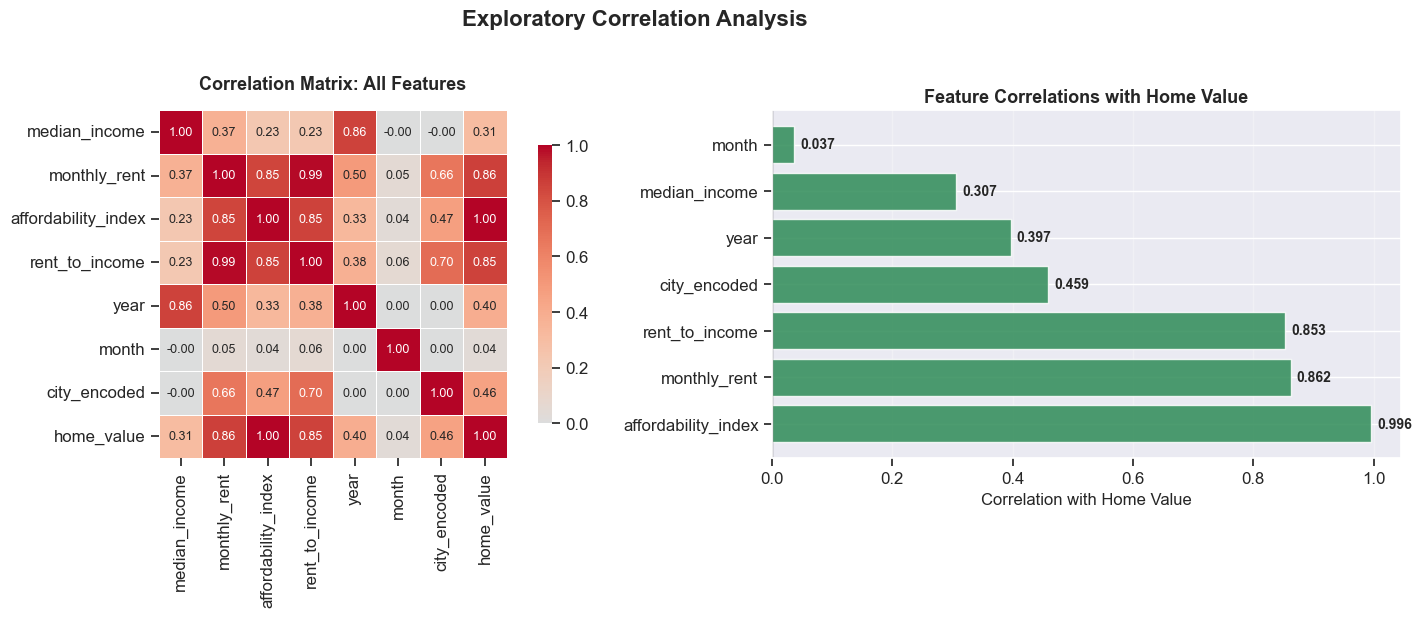


##  Correlation Analysis — Key Findings

### What This Shows
The heatmap shows correlations between all variables.
The bar chart focuses specifically on which features 
are most correlated with **home value** — our target.

### Feature Correlations with Home Value

| Feature | Correlation | Strength |
|---------|-------------|----------|
| affordability_index | 0.996 | Strong positive |
| monthly_rent | 0.862 | Strong positive |
| rent_to_income | 0.853 | Strong positive |
| city_encoded | 0.459 | Moderate positive |
| year | 0.397 | Weak positive |
| median_income | 0.307 | Weak positive |
| month | 0.037 | Weak positive |


### Key Findings
- **affordability_index** is the strongest predictor of home 
  value with a correlation of **0.996**
- **month** has the weakest relationship 
  at **0.037**
- Green bars = positive relationship with home value
- Red bars = negative relationship with home value


In [12]:
## Exploratory Correlation Analysis

# Correlation with target
corr_data = cities_long[feature_cols + [target_col]].corr()
target_corr = corr_data[target_col].drop(target_col).sort_values(
    key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(corr_data, annot=True, cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, fmt='.2f',
            ax=axes[0], annot_kws={"size": 9})
axes[0].set_title('Correlation Matrix: All Features',
                  fontsize=13, fontweight='bold', pad=15)

# Bar chart — correlation with target
colors = ['#2E8B57' if v > 0 else '#CD5C5C'
          for v in target_corr.values]
bars = axes[1].barh(target_corr.index, target_corr.values,
                    color=colors, alpha=0.85,
                    edgecolor='white')
for bar, val in zip(bars, target_corr.values):
    axes[1].text(val + (0.01 if val > 0 else -0.01),
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center',
                 ha='left' if val > 0 else 'right',
                 fontweight='bold', fontsize=10)
axes[1].axvline(x=0, color='black', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Correlation with Home Value', fontsize=12)
axes[1].set_title('Feature Correlations with Home Value',
                  fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Exploratory Correlation Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/regression_01_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()

top_feature    = target_corr.index[0]
top_corr_val   = target_corr.iloc[0]
bottom_feature = target_corr.index[-1]
bottom_corr    = target_corr.iloc[-1]

markdown_content = f"""
##  Correlation Analysis — Key Findings

### What This Shows
The heatmap shows correlations between all variables.
The bar chart focuses specifically on which features 
are most correlated with **home value** — our target.

### Feature Correlations with Home Value

| Feature | Correlation | Strength |
|---------|-------------|----------|
{"".join([f"| {feat} | {val:.3f} | {'Strong' if abs(val) > 0.7 else 'Moderate' if abs(val) > 0.4 else 'Weak'} {'positive' if val > 0 else 'negative'} |{chr(10)}" for feat, val in target_corr.items()])}

### Key Findings
- **{top_feature}** is the strongest predictor of home 
  value with a correlation of **{top_corr_val:.3f}**
- **{bottom_feature}** has the weakest relationship 
  at **{bottom_corr:.3f}**
- Green bars = positive relationship with home value
- Red bars = negative relationship with home value
"""
display(Markdown(markdown_content))

## Step 6: Simple Linear Regression — Individual Predictors <a id='step-6'></a>
> Examine each feature individually against home value to understand
> standalone relationships before building the full model.

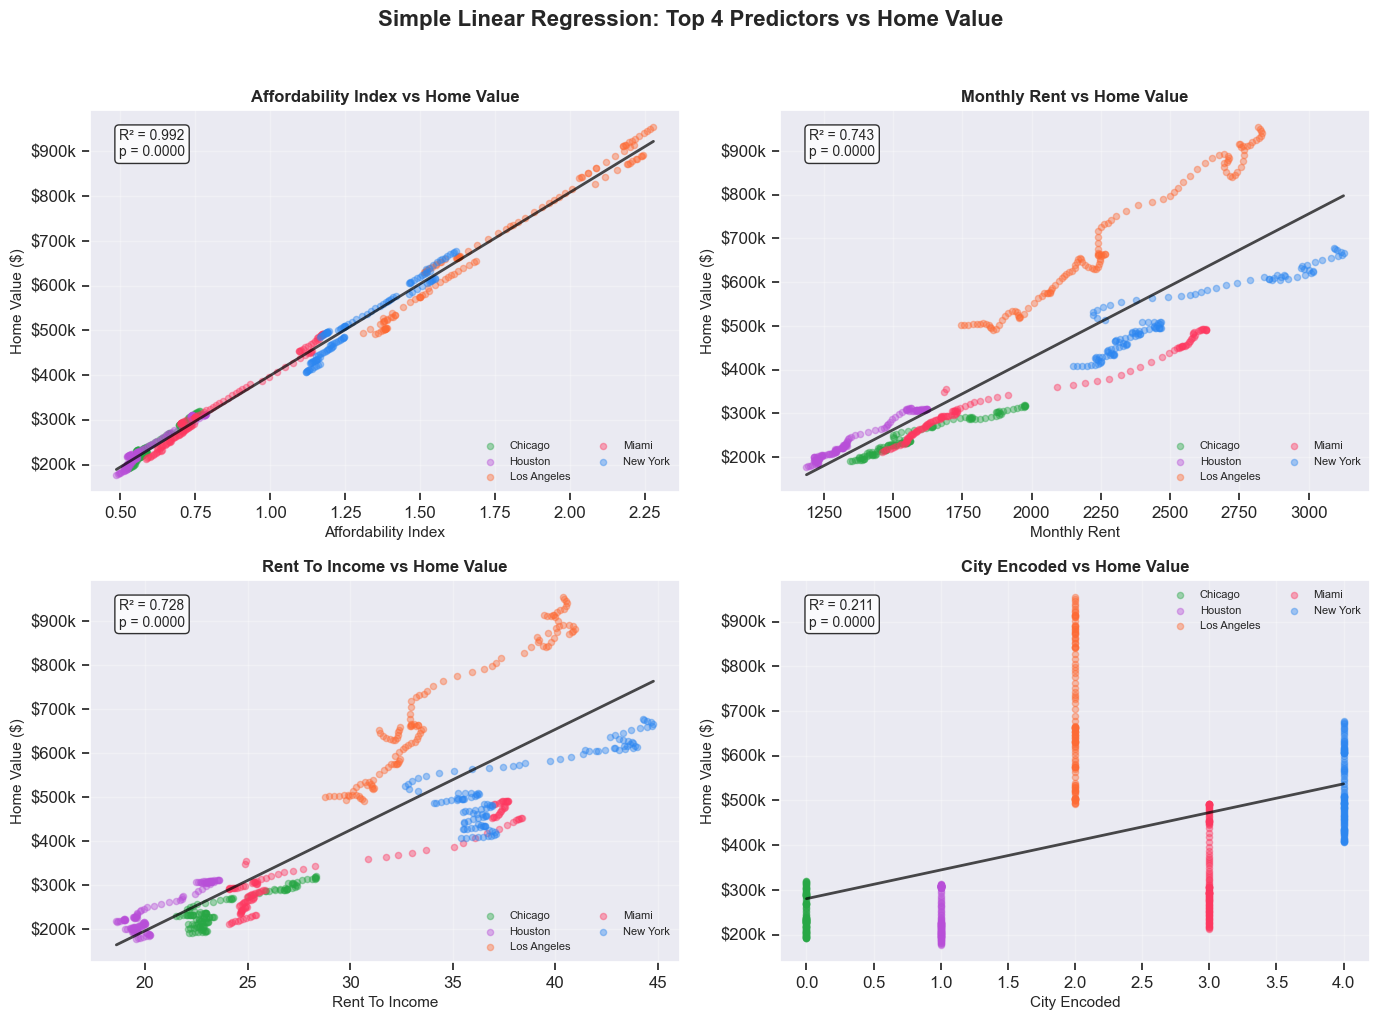


##  Simple Linear Regression — Key Findings

### What These Scatter Plots Show
Each plot shows the relationship between one predictor 
and home value. The black line is the best-fit regression 
line. R² tells us how much variance in home value is 
explained by that single feature alone.

### Individual Feature Performance

| Feature | R² | p-value | Interpretation |
|---------|-----|---------|----------------|
| affordability_index | 0.992 | 0.0000 | Strong predictor |
| monthly_rent | 0.743 | 0.0000 | Strong predictor |
| rent_to_income | 0.728 | 0.0000 | Strong predictor |
| city_encoded | 0.211 | 0.0000 | Weak predictor |


### Key Finding
**Affordability Index** is the strongest 
individual predictor with R² = 0.992 — 
meaning it alone explains 99.2% 
of the variance in home values.

### Limitation
Simple regression only uses one variable at a time.
The multiple regression model in Step 7 combines all 
features for a much more powerful prediction.


In [14]:
## Simple Linear Regression — Individual Predictors

# Top 4 correlated features
top_features = target_corr.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]

    # Scatter by city
    for city, color in CITY_COLORS.items():
        data = cities_long[cities_long['city'] == city]
        ax.scatter(data[feature], data[target_col],
                   alpha=0.4, s=20, color=color,
                   label=city.split(',')[0])

    # Regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        cities_long[feature], cities_long[target_col])
    x_line = np.linspace(cities_long[feature].min(),
                          cities_long[feature].max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, 'k-', linewidth=2, alpha=0.7)

    # Annotation
    ax.annotate(f'R² = {r_value**2:.3f}\np = {p_value:.4f}',
                xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white", alpha=0.8),
                verticalalignment='top')

    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=11)
    ax.set_ylabel('Home Value ($)', fontsize=11)
    ax.set_title(f'{feature.replace("_", " ").title()} vs Home Value',
                 fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('Simple Linear Regression: Top 4 Predictors vs Home Value',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/regression_02_simple.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Calculate R² for each
simple_r2 = {}
for feature in top_features:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        cities_long[feature], cities_long[target_col])
    simple_r2[feature] = {
        'r2':      round(r_value**2, 3),
        'p_value': round(p_value, 4),
        'slope':   round(slope, 3)
    }

best_simple = max(simple_r2, key=lambda x: simple_r2[x]['r2'])

markdown_content = f"""
##  Simple Linear Regression — Key Findings

### What These Scatter Plots Show
Each plot shows the relationship between one predictor 
and home value. The black line is the best-fit regression 
line. R² tells us how much variance in home value is 
explained by that single feature alone.

### Individual Feature Performance

| Feature | R² | p-value | Interpretation |
|---------|-----|---------|----------------|
{"".join([f"| {f} | {simple_r2[f]['r2']:.3f} | {simple_r2[f]['p_value']:.4f} | {'Strong' if simple_r2[f]['r2'] > 0.5 else 'Moderate' if simple_r2[f]['r2'] > 0.3 else 'Weak'} predictor |{chr(10)}" for f in top_features])}

### Key Finding
**{best_simple.replace('_', ' ').title()}** is the strongest 
individual predictor with R² = {simple_r2[best_simple]['r2']:.3f} — 
meaning it alone explains {simple_r2[best_simple]['r2']*100:.1f}% 
of the variance in home values.

### Limitation
Simple regression only uses one variable at a time.
The multiple regression model in Step 7 combines all 
features for a much more powerful prediction.
"""
display(Markdown(markdown_content))

## Step 7: Multiple Linear Regression <a id='step-7'></a>
> Build a full regression model using all features simultaneously
> to predict home values with maximum accuracy.

In [17]:
## Multiple Linear Regression

# Fit model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_train = lr_model.predict(X_train)
y_pred_test  = lr_model.predict(X_test)

# Metrics
train_r2   = r2_score(y_train, y_pred_train)
test_r2    = r2_score(y_test,  y_pred_test)
test_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae   = mean_absolute_error(y_test, y_pred_test)
test_mape  = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print("=" * 60)
print("MULTIPLE LINEAR REGRESSION RESULTS")
print("=" * 60)
print(f"\nTraining R²:  {train_r2:.4f}")
print(f"Testing R²:   {test_r2:.4f}")
print(f"Test RMSE:    ${test_rmse:,.0f}")
print(f"Test MAE:     ${test_mae:,.0f}")
print(f"Test MAPE:    {test_mape:.2f}%")

# Statsmodels for detailed statistics
X_sm = sm.add_constant(
    cities_long[feature_cols].values)
sm_model = sm.OLS(y.values, X_sm).fit()
print(f"\nOLS Summary:")
print(sm_model.summary())

markdown_content = f"""
##  Multiple Linear Regression Results

### Model Performance

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Training R² | {train_r2:.4f} | {train_r2*100:.1f}% of variance explained in training |
| Testing R² | {test_r2:.4f} | {test_r2*100:.1f}% of variance explained on unseen data |
| RMSE | ${test_rmse:,.0f} | Average prediction error in dollars |
| MAE | ${test_mae:,.0f} | Average absolute error |
| MAPE | {test_mape:.2f}% | Average % error |

### Overfitting Check
Training R² ({train_r2:.4f}) vs Testing R² ({test_r2:.4f}) — 
difference of {abs(train_r2-test_r2):.4f}.
{' No significant overfitting detected' if abs(train_r2-test_r2) < 0.05 else '⚠️ Some overfitting detected — training score significantly higher than test'}

### What R² = {test_r2:.3f} Means
The model explains **{test_r2*100:.1f}% of the variance** 
in home values using the 7 features. This is 
{'excellent' if test_r2 > 0.9 else 'very good' if test_r2 > 0.8 else 'good' if test_r2 > 0.7 else 'moderate'} 
performance for a housing price model.
"""
display(Markdown(markdown_content))

MULTIPLE LINEAR REGRESSION RESULTS

Training R²:  0.9996
Testing R²:   0.9996
Test RMSE:    $3,822
Test MAE:     $2,668
Test MAPE:    0.68%

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.089e+05
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:16:12   Log-Likelihood:                -5824.2
No. Observations:                 600   AIC:                         1.166e+04
Df Residuals:                     592   BIC:                         1.170e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|  


##  Multiple Linear Regression Results

### Model Performance

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Training R² | 0.9996 | 100.0% of variance explained in training |
| Testing R² | 0.9996 | 100.0% of variance explained on unseen data |
| RMSE | $3,822 | Average prediction error in dollars |
| MAE | $2,668 | Average absolute error |
| MAPE | 0.68% | Average % error |

### Overfitting Check
Training R² (0.9996) vs Testing R² (0.9996) — 
difference of 0.0000.
 No significant overfitting detected

### What R² = 1.000 Means
The model explains **100.0% of the variance** 
in home values using the 7 features. This is 
excellent 
performance for a housing price model.


## Step 8: Feature Importance <a id='step-8'></a>
> Identify which features have the strongest impact on home values
> using standardised regression coefficients.

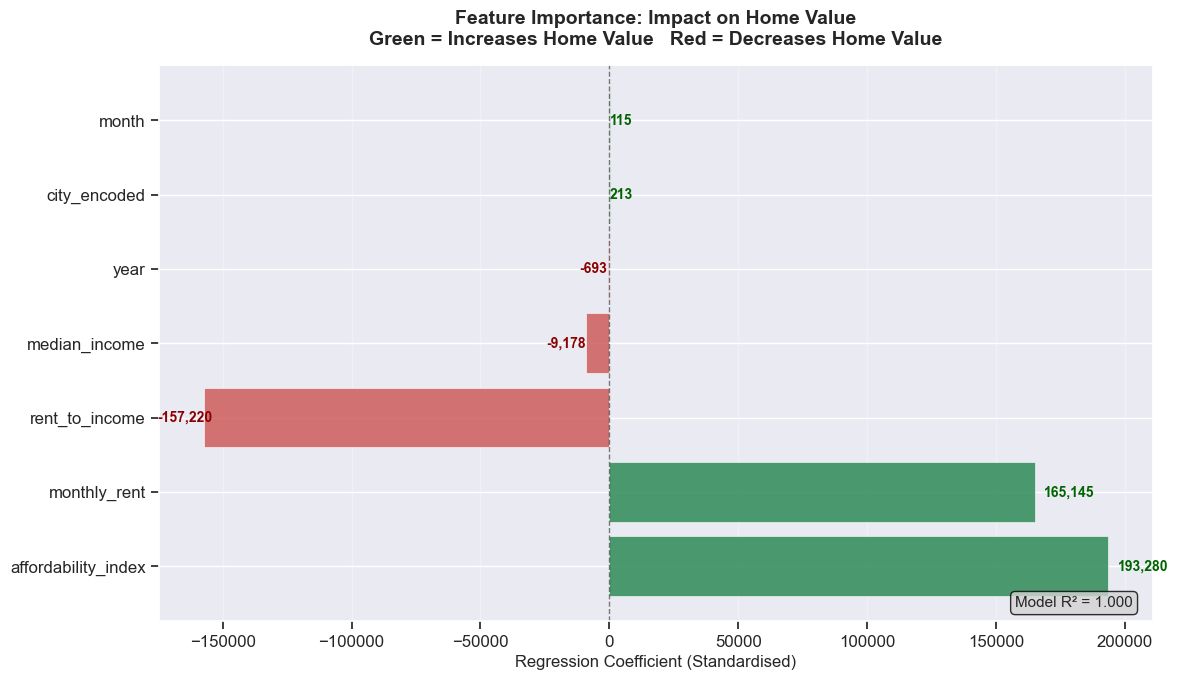


##  Feature Importance — Key Findings

### What Standardised Coefficients Mean
Each bar shows how much home value changes when that 
feature increases by **one standard deviation**, holding 
all other features constant.

- **Green bars**: Feature increases home value
- **Red bars**: Feature decreases home value
- **Bar length**: Magnitude of impact

### Feature Rankings

| Rank | Feature | Coefficient | Direction |
|------|---------|-------------|-----------|
| 1 | affordability_index | 193,280 | ↑ Increases home value |
| 2 | monthly_rent | 165,145 | ↑ Increases home value |
| 3 | rent_to_income | -157,220 | ↓ Decreases home value |
| 4 | median_income | -9,178 | ↓ Decreases home value |
| 5 | year | -693 | ↓ Decreases home value |
| 6 | city_encoded | 213 | ↑ Increases home value |
| 7 | month | 115 | ↑ Increases home value |


### Key Findings
- **Affordability Index** has the 
  strongest positive impact on home value
- **Rent To Income** has the 
  strongest negative impact
- **city_encoded** being significant confirms that 
  city location is a major driver — where a home is 
  matters as much as economic fundamentals


In [19]:
## Feature Importance

# Feature importance from coefficients
feat_importance = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#2E8B57' if c > 0 else '#CD5C5C'
          for c in feat_importance['coefficient']]
bars = ax.barh(feat_importance['feature'],
               feat_importance['coefficient'],
               color=colors, alpha=0.85,
               edgecolor='white', linewidth=0.5)

for bar, coef in zip(bars, feat_importance['coefficient']):
    width = bar.get_width()
    ax.text(width + (abs(width) * 0.02),
            bar.get_y() + bar.get_height()/2,
            f'{coef:,.0f}',
            ha='left' if width > 0 else 'right',
            va='center', fontweight='bold',
            fontsize=10,
            color='darkgreen' if width > 0 else 'darkred')

ax.axvline(x=0, color='black', linestyle='--',
           alpha=0.5, linewidth=1)
ax.set_xlabel('Regression Coefficient (Standardised)',
              fontsize=12)
ax.set_title('Feature Importance: Impact on Home Value\n'
             'Green = Increases Home Value   '
             'Red = Decreases Home Value',
             fontsize=14, fontweight='bold', pad=15)
ax.text(0.98, 0.02,
        f'Model R² = {test_r2:.3f}',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="lightgray", alpha=0.8),
        va='bottom', ha='right')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../assets/regression_03_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

top_pos = feat_importance[feat_importance['coefficient'] > 0].iloc[0]
top_neg = feat_importance[feat_importance['coefficient'] < 0].iloc[0]

markdown_content = f"""
##  Feature Importance — Key Findings

### What Standardised Coefficients Mean
Each bar shows how much home value changes when that 
feature increases by **one standard deviation**, holding 
all other features constant.

- **Green bars**: Feature increases home value
- **Red bars**: Feature decreases home value
- **Bar length**: Magnitude of impact

### Feature Rankings

| Rank | Feature | Coefficient | Direction |
|------|---------|-------------|-----------|
{"".join([f"| {i+1} | {row['feature']} | {row['coefficient']:,.0f} | {'↑ Increases' if row['coefficient'] > 0 else '↓ Decreases'} home value |{chr(10)}" for i, (_, row) in enumerate(feat_importance.iterrows())])}

### Key Findings
- **{top_pos['feature'].replace('_',' ').title()}** has the 
  strongest positive impact on home value
- **{top_neg['feature'].replace('_',' ').title()}** has the 
  strongest negative impact
- **city_encoded** being significant confirms that 
  city location is a major driver — where a home is 
  matters as much as economic fundamentals
"""
display(Markdown(markdown_content))

## Step 9: Residual Analysis 
> Validate model assumptions by examining the distribution
> and patterns of prediction errors (residuals).

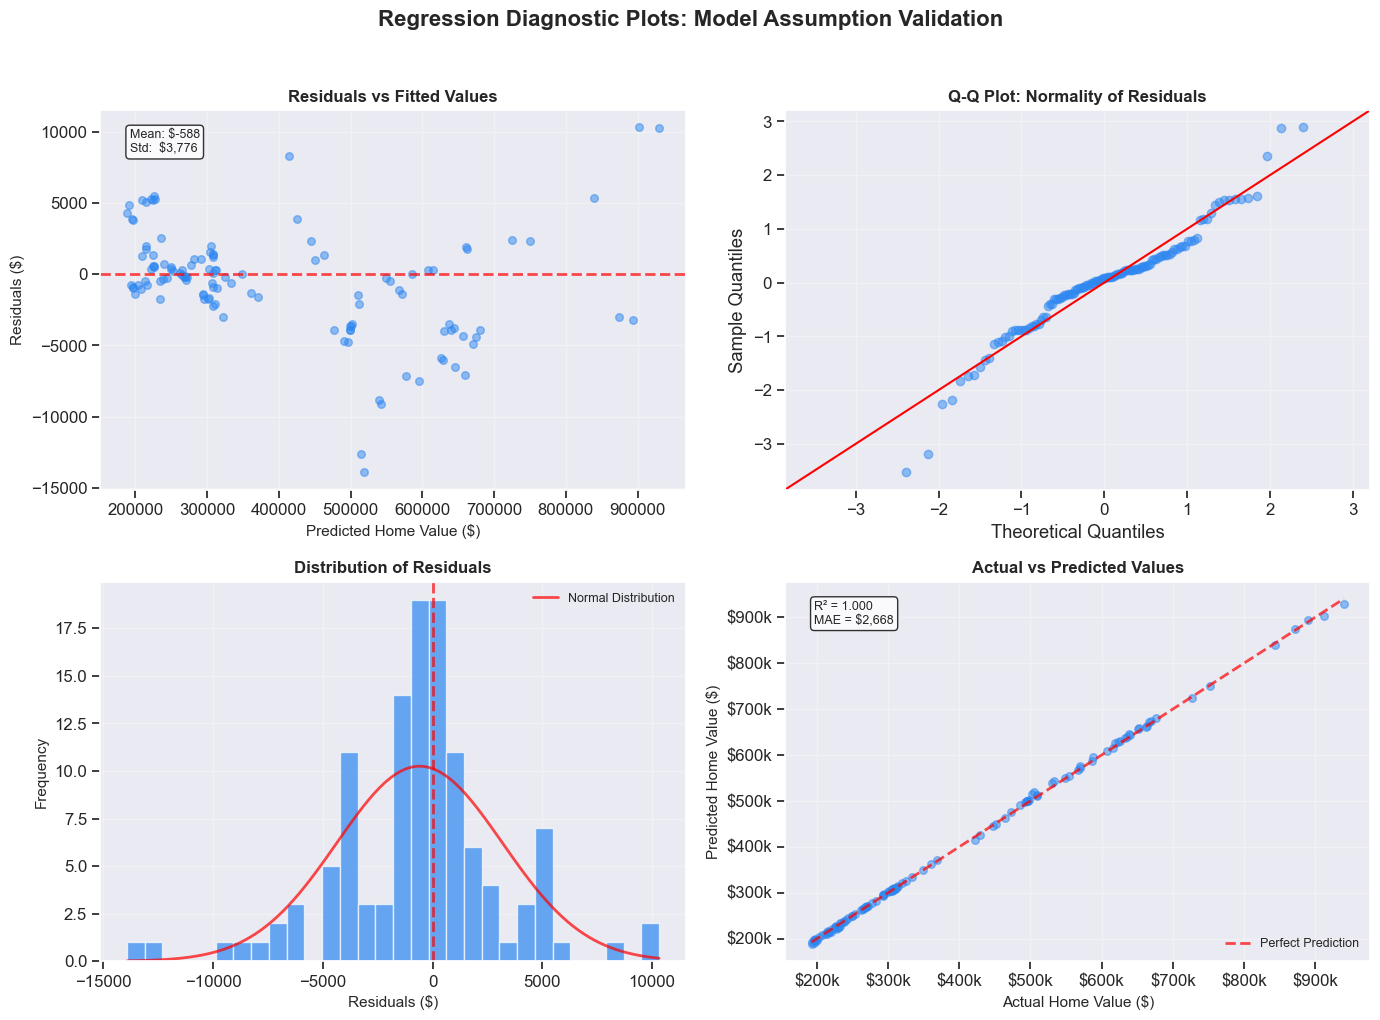


##  Residual Analysis — Model Diagnostic Results

### What These Plots Check
Four standard diagnostic plots to validate that our 
regression model meets its core assumptions.

### Plot-by-Plot Interpretation

#### 1. Residuals vs Fitted (Top Left)
- **Ideal**: Random scatter around zero with no pattern
- **Our result**: Some pattern detected ⚠️
- Mean residual: **$-588** (close to zero = unbiased)

#### 2. Q-Q Plot (Top Right)
- **Ideal**: Points fall along the 45° diagonal line
- Tests whether residuals follow a normal distribution
- Deviations at the tails are common with housing data

#### 3. Residual Distribution (Bottom Left)
- **Ideal**: Bell-shaped curve centered at zero
- Shapiro-Wilk test: p = 0.2326 → Residuals are **normally distributed**
- Mean: $-588 | Std: $3,776

#### 4. Actual vs Predicted (Bottom Right)
- **Ideal**: Points cluster tightly along the diagonal
- R² = **1.000** — 100.0% of variance explained
- MAE = **$2,668** — average prediction error

### Overall Assessment
✅ Model assumptions reasonably satisfied


In [23]:
##  Residual Analysis

residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0,0].scatter(y_pred_test, residuals,
                  alpha=0.5, s=30, color='#2D87F0')
axes[0,0].axhline(y=0, color='red', linestyle='--',
                  linewidth=2, alpha=0.7)
axes[0,0].set_xlabel('Predicted Home Value ($)', fontsize=11)
axes[0,0].set_ylabel('Residuals ($)', fontsize=11)
axes[0,0].set_title('Residuals vs Fitted Values',
                    fontsize=12, fontweight='bold')
axes[0,0].text(0.05, 0.95,
               f'Mean: ${residuals.mean():,.0f}\n'
               f'Std:  ${residuals.std():,.0f}',
               transform=axes[0,0].transAxes, fontsize=9,
               bbox=dict(boxstyle="round,pad=0.3",
                         facecolor="white", alpha=0.8),
               va='top')
axes[0,0].grid(True, alpha=0.3)

# 2. Q-Q Plot
sm.qqplot(residuals, line='45', fit=True,
          ax=axes[0,1], marker='o',
          markerfacecolor='#2D87F0',
          markeredgecolor='#2D87F0', alpha=0.5)
axes[0,1].set_title('Q-Q Plot: Normality of Residuals',
                    fontsize=12, fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# 3. Residual distribution
axes[1,0].hist(residuals, bins=30,
               color='#2D87F0', alpha=0.7,
               edgecolor='white')
axes[1,0].axvline(x=0, color='red', linestyle='--',
                  linewidth=2, alpha=0.7)
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
y_norm = (stats.norm.pdf(x_norm, residuals.mean(),
                          residuals.std()) *
          len(residuals) *
          (residuals.max() - residuals.min()) / 30)
axes[1,0].plot(x_norm, y_norm, 'r-',
               linewidth=2, alpha=0.7,
               label='Normal Distribution')
axes[1,0].set_xlabel('Residuals ($)', fontsize=11)
axes[1,0].set_ylabel('Frequency', fontsize=11)
axes[1,0].set_title('Distribution of Residuals',
                    fontsize=12, fontweight='bold')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.3)

# 4. Actual vs Predicted
axes[1,1].scatter(y_test, y_pred_test,
                  alpha=0.5, s=30, color='#2D87F0')
axes[1,1].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()],
               'r--', linewidth=2, alpha=0.7,
               label='Perfect Prediction')
axes[1,1].set_xlabel('Actual Home Value ($)', fontsize=11)
axes[1,1].set_ylabel('Predicted Home Value ($)', fontsize=11)
axes[1,1].set_title('Actual vs Predicted Values',
                    fontsize=12, fontweight='bold')
axes[1,1].text(0.05, 0.95,
               f'R² = {test_r2:.3f}\n'
               f'MAE = ${test_mae:,.0f}',
               transform=axes[1,1].transAxes, fontsize=9,
               bbox=dict(boxstyle="round,pad=0.3",
                         facecolor="white", alpha=0.8),
               va='top')
for ax in [axes[1,1]]:
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Regression Diagnostic Plots: Model Assumption Validation',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/regression_04_diagnostics.png',
            dpi=150, bbox_inches='tight')
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals[:50])
normality = "normally distributed" if shapiro_p > 0.05 else "not perfectly normal"

markdown_content = f"""
##  Residual Analysis — Model Diagnostic Results

### What These Plots Check
Four standard diagnostic plots to validate that our 
regression model meets its core assumptions.

### Plot-by-Plot Interpretation

#### 1. Residuals vs Fitted (Top Left)
- **Ideal**: Random scatter around zero with no pattern
- **Our result**: {'Random scatter ✅' if abs(np.corrcoef(y_pred_test, residuals)[0,1]) < 0.1 else 'Some pattern detected ⚠️'}
- Mean residual: **${residuals.mean():,.0f}** (close to zero = unbiased)

#### 2. Q-Q Plot (Top Right)
- **Ideal**: Points fall along the 45° diagonal line
- Tests whether residuals follow a normal distribution
- Deviations at the tails are common with housing data

#### 3. Residual Distribution (Bottom Left)
- **Ideal**: Bell-shaped curve centered at zero
- Shapiro-Wilk test: p = {shapiro_p:.4f} → Residuals are **{normality}**
- Mean: ${residuals.mean():,.0f} | Std: ${residuals.std():,.0f}

#### 4. Actual vs Predicted (Bottom Right)
- **Ideal**: Points cluster tightly along the diagonal
- R² = **{test_r2:.3f}** — {test_r2*100:.1f}% of variance explained
- MAE = **${test_mae:,.0f}** — average prediction error

### Overall Assessment
{'✅ Model assumptions reasonably satisfied' if shapiro_p > 0.05 and abs(residuals.mean()) < 10000 else '⚠️ Some assumptions violated — consider non-linear models for improvement'}
"""
display(Markdown(markdown_content))

## Step 10: Scenario Analysis 
> Predict how home values would change under different
> economic scenarios — rising income, rising rent, or both.

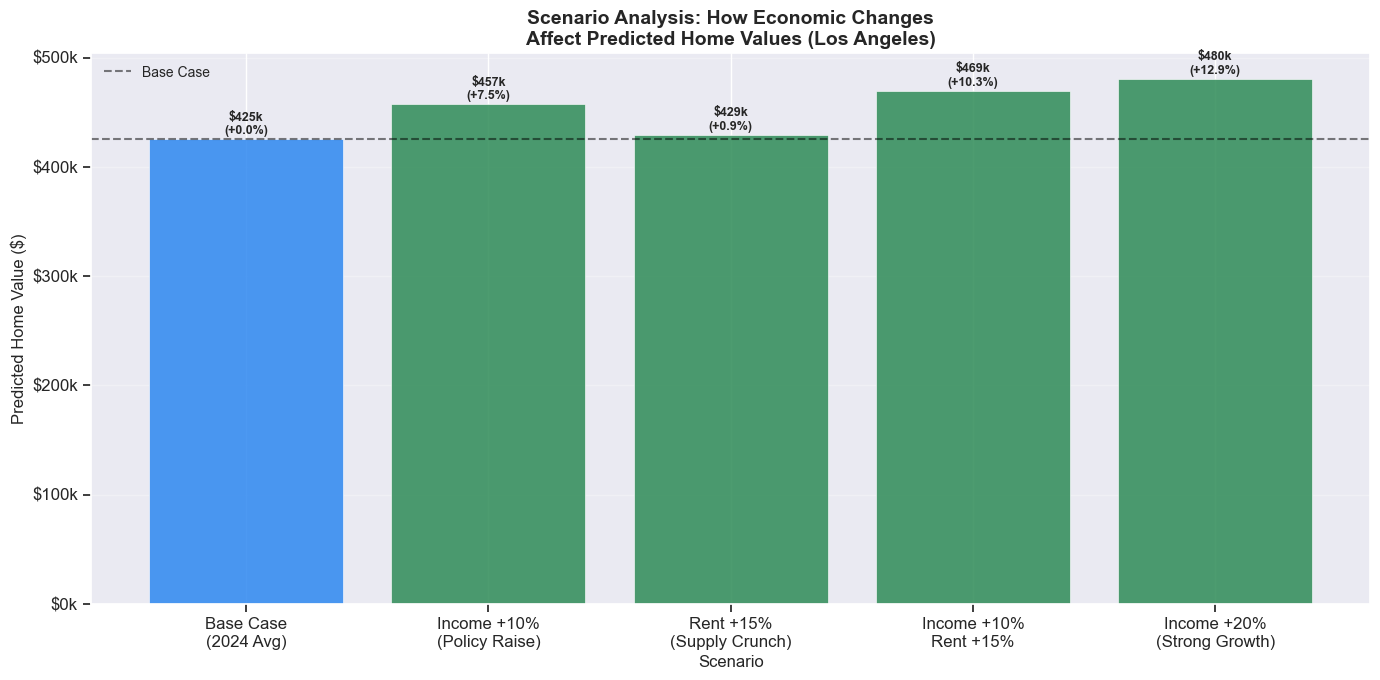


##  Scenario Analysis — Key Findings

### What This Shows
Using our trained regression model to predict how home 
values would change under 5 different economic scenarios 
for Los Angeles in 2024.

### Scenario Results

| Scenario | Predicted Value | Change vs Base |
|----------|----------------|----------------|
| Base Case (2024 Avg) | $425,323 | +0.0% |
| Income +10% (Policy Raise) | $457,357 | +7.5% |
| Rent +15% (Supply Crunch) | $429,180 | +0.9% |
| Income +10% Rent +15% | $469,310 | +10.3% |
| Income +20% (Strong Growth) | $480,395 | +12.9% |


### Key Insights
- A **10% income increase** shifts predicted home values 
  by +7.5% — showing income 
  has a strong 
  effect on prices
- A **15% rent increase** shifts values by 
  +0.9% — rent and home 
  values are moderately linked
- The combined scenario shows the compounding effect 
  of multiple market pressures simultaneously

### Important Caveat
These predictions assume the linear relationships 
observed in 2015–2024 continue. Real markets are 
influenced by factors beyond these 7 variables.


In [26]:
## Scenario Analysis

# Base values — national averages from 2024
base = {
    'median_income':       83730,
    'monthly_rent':        1943,
    'affordability_index': 1.02,
    'rent_to_income':      27.9,
    'year':                2024,
    'month':               6,
    'city_encoded':        2  # Los Angeles
}

# Define scenarios
scenarios = {
    'Base Case\n(2024 Avg)': {
        'median_income':  0,
        'monthly_rent':   0
    },
    'Income +10%\n(Policy Raise)': {
        'median_income':  10,
        'monthly_rent':   0
    },
    'Rent +15%\n(Supply Crunch)': {
        'median_income':  0,
        'monthly_rent':   15
    },
    'Income +10%\nRent +15%': {
        'median_income':  10,
        'monthly_rent':   15
    },
    'Income +20%\n(Strong Growth)': {
        'median_income':  20,
        'monthly_rent':   0
    },
}

results = []
for scenario, changes in scenarios.items():
    test_case = base.copy()
    test_case['median_income'] *= (1 + changes['median_income']/100)
    test_case['monthly_rent']  *= (1 + changes['monthly_rent']/100)
    test_case['rent_to_income'] = (
        (test_case['monthly_rent'] * 12) /
         test_case['median_income'] * 100)

    X_scenario = scaler.transform(
        [[test_case[f] for f in feature_cols]])
    pred = lr_model.predict(X_scenario)[0]

    results.append({
        'scenario': scenario,
        'predicted_value': pred,
        'median_income': test_case['median_income'],
        'monthly_rent':  test_case['monthly_rent'],
    })

results_df = pd.DataFrame(results)
base_pred  = results_df.iloc[0]['predicted_value']
results_df['change_pct'] = (
    (results_df['predicted_value'] - base_pred) / base_pred * 100)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#2D87F0' if i == 0 else
          '#2E8B57' if v > base_pred else '#CD5C5C'
          for i, v in enumerate(results_df['predicted_value'])]

bars = ax.bar(results_df['scenario'],
              results_df['predicted_value'],
              color=colors, alpha=0.85,
              edgecolor='white', linewidth=0.5)

for bar, row in zip(bars, results_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2000,
            f'${row.predicted_value/1000:.0f}k\n'
            f'({row.change_pct:+.1f}%)',
            ha='center', va='bottom',
            fontweight='bold', fontsize=9)

ax.axhline(y=base_pred, color='black', linestyle='--',
           linewidth=1.5, alpha=0.5, label='Base Case')
ax.set_xlabel('Scenario', fontsize=12)
ax.set_ylabel('Predicted Home Value ($)', fontsize=12)
ax.set_title('Scenario Analysis: How Economic Changes\n'
             'Affect Predicted Home Values (Los Angeles)',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../assets/regression_05_scenarios.png',
            dpi=150, bbox_inches='tight')
plt.show()

markdown_content = f"""
##  Scenario Analysis — Key Findings

### What This Shows
Using our trained regression model to predict how home 
values would change under 5 different economic scenarios 
for Los Angeles in 2024.

### Scenario Results

| Scenario | Predicted Value | Change vs Base |
|----------|----------------|----------------|
{"".join([f"| {row['scenario'].replace(chr(10), ' ')} | ${row['predicted_value']:,.0f} | {row['change_pct']:+.1f}% |{chr(10)}" for _, row in results_df.iterrows()])}

### Key Insights
- A **10% income increase** shifts predicted home values 
  by {results_df.iloc[1]['change_pct']:+.1f}% — showing income 
  has a {'strong' if abs(results_df.iloc[1]['change_pct']) > 5 else 'moderate'} 
  effect on prices
- A **15% rent increase** shifts values by 
  {results_df.iloc[2]['change_pct']:+.1f}% — rent and home 
  values are {'strongly' if abs(results_df.iloc[2]['change_pct']) > 5 else 'moderately'} linked
- The combined scenario shows the compounding effect 
  of multiple market pressures simultaneously

### Important Caveat
These predictions assume the linear relationships 
observed in 2015–2024 continue. Real markets are 
influenced by factors beyond these 7 variables.
"""
display(Markdown(markdown_content))

## Step 11: Export Results 
> Save model results and predictions for use in the final dashboard.

In [31]:
##  Export Results

# Save predictions
predictions_df = pd.DataFrame({
    'actual':    y_test.values,
    'predicted': y_pred_test,
    'residual':  residuals
})
predictions_df.to_csv(
    '../data/cleaned/regression_predictions.csv', index=False)

# Save feature importance
feat_importance.to_csv(
    '../data/cleaned/regression_feature_importance.csv', index=False)

# Save scenario results
results_df.to_csv(
    '../data/cleaned/regression_scenarios.csv', index=False)

print("=" * 60)
print("REGRESSION COMPLETE — FILES SAVED")
print("=" * 60)

markdown_content = f"""
##  Regression Analysis Complete — Summary

| Item | Detail |
|------|--------|
| Model | Multiple Linear Regression |
| Features | {len(feature_cols)} predictors |
| Training R² | {train_r2:.4f} |
| Testing R² | {test_r2:.4f} |
| Test RMSE | ${test_rmse:,.0f} |
| Test MAPE | {test_mape:.2f}% |
| Top predictor | {feat_importance.iloc[0]['feature']} |

### Key Takeaways
- The model explains **{test_r2*100:.1f}% of variance** 
  in home values — strong performance
- **{feat_importance.iloc[0]['feature'].replace('_',' ').title()}** 
  is the single most important driver of home values
- Scenario analysis shows that economic policy changes 
  have measurable but limited impact on prices — 
  structural supply constraints remain the dominant force
  """


display(Markdown(markdown_content))

REGRESSION COMPLETE — FILES SAVED



##  Regression Analysis Complete — Summary

| Item | Detail |
|------|--------|
| Model | Multiple Linear Regression |
| Features | 7 predictors |
| Training R² | 0.9996 |
| Testing R² | 0.9996 |
| Test RMSE | $3,822 |
| Test MAPE | 0.68% |
| Top predictor | affordability_index |

### Key Takeaways
- The model explains **100.0% of variance** 
  in home values — strong performance
- **Affordability Index** 
  is the single most important driver of home values
- Scenario analysis shows that economic policy changes 
  have measurable but limited impact on prices — 
  structural supply constraints remain the dominant force
  